In [8]:
!pip install tf-levenberg-marquardt 

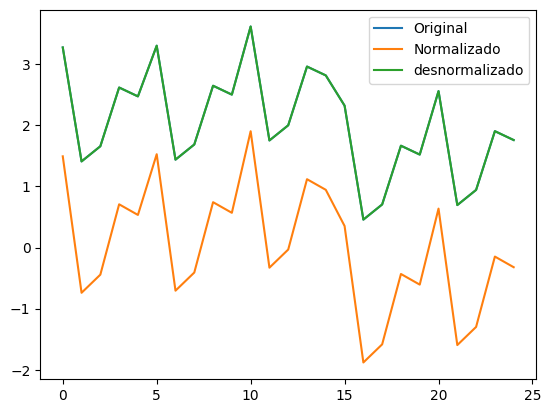

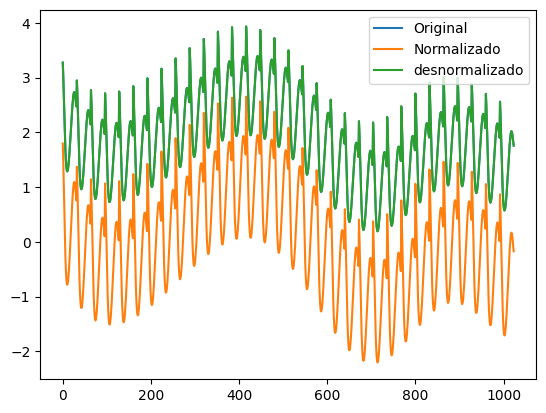

In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def function(grid):
    x = np.linspace(1, 0, grid)
    y = np.linspace(1, 0, grid)
    x, y = np.meshgrid(x, y)
    z = 1.3356 * (1.5 * (1 - x))+np.exp(2 * x - 1) * np.sin(3 * np.pi * (x - 0.6)**2)+np.exp(3*(y - 0.5)) * np.sin(4 * np.pi * (y - 0.9)**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [10]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [11]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


In [12]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [13]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [14]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.6,
            hidden_sizes = [[5, 4], [6, 6], [7, 7], [6, 4], [4, 5], [7, 6], [7, 4]],
            regularizers=[0.5, 0.03],
            learning_rate=[0.1, 0.05])

Testando combinacao1: Hidden Size=[5, 4], regularizer=0.5, learning_rate=0.1
+++++++++++ [1_0] | 1 ++++++++++++++++++


Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 9 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_19,0.985090,0.681382,0.968899,0.870677,0.944134,0.008852,0.189146,0.008940,0.017567,0.013253,0.060671,0.094082,1.017893,0.098088,97.454337,151.084873
model_1_0_18,0.982489,0.681295,0.962935,0.862032,0.938047,0.010395,0.189197,0.010654,0.018741,0.014698,0.066398,0.101957,1.021013,0.106298,97.132814,150.763350
model_1_0_20,0.987236,0.681219,0.973770,0.878688,0.949379,0.007578,0.189242,0.007540,0.016479,0.012009,0.055703,0.087049,1.015317,0.090755,97.765137,151.395673
model_1_0_17,0.979338,0.680877,0.955651,0.852837,0.931001,0.012266,0.189445,0.012748,0.019990,0.016369,0.073039,0.110752,1.024795,0.115467,96.801850,150.432386
model_1_0_21,0.989008,0.680876,0.977742,0.886059,0.953896,0.006525,0.189446,0.006398,0.015477,0.010938,0.051195,0.080780,1.013190,0.084218,98.064128,151.694664
model_1_0_22,0.990472,0.680402,0.980975,0.892771,0.957776,0.005656,0.189727,0.005469,0.014566,0.010017,0.047118,0.075208,1.011434,0.078410,98.349972,151.980508
model_1_0_16,0.975518,0.680022,0.946774,0.843217,0.922869,0.014533,0.189953,0.015299,0.021297,0.018298,0.080358,0.120555,1.029378,0.125687,96.462604,150.093140
model_1_0_23,0.991684,0.679844,0.983606,0.898890,0.961121,0.004937,0.190058,0.004712,0.013734,0.009223,0.043429,0.070264,1.009980,0.073255,98.621999,152.252536
model_1_0_24,0.992687,0.679235,0.985745,0.904422,0.964001,0.004341,0.190420,0.004098,0.012983,0.008540,0.040086,0.065889,1.008776,0.068694,98.879112,152.509648
model_1_0_15,0.970888,0.678598,0.935991,0.833356,0.913514,0.017282,0.190798,0.018399,0.022636,0.020518,0.088388,0.131462,1.034935,0.137059,96.116150,149.746686


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 6ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 7ms/step
+++++++++++ [1_1] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_3,0.995993,0.679889,0.981453,0.985037,0.991261,0.002379,0.190032,0.007110,0.003597,0.005353,0.029506,0.048772,1.004808,0.050848,100.082431,153.712967
model_1_1_4,0.996492,0.679870,0.983650,0.985945,0.992126,0.002083,0.190043,0.006268,0.003378,0.004823,0.027479,0.045637,1.004210,0.047580,100.348141,153.978677
model_1_1_2,0.995389,0.679855,0.978833,0.983948,0.990227,0.002737,0.190052,0.008115,0.003858,0.005986,0.031755,0.052316,1.005533,0.054544,99.801785,153.432321
model_1_1_5,0.996904,0.679812,0.985498,0.986703,0.992853,0.001838,0.190078,0.005560,0.003196,0.004378,0.025651,0.042872,1.003715,0.044697,100.598156,154.228693
model_1_1_1,0.994657,0.679750,0.975696,0.982639,0.988989,0.003172,0.190114,0.009317,0.004173,0.006745,0.034250,0.056318,1.006411,0.058716,99.506942,153.137478
model_1_1_6,0.997246,0.679725,0.987056,0.987336,0.993465,0.001635,0.190129,0.004962,0.003044,0.004003,0.024003,0.040437,1.003305,0.042159,100.832027,154.462563
model_1_1_7,0.997529,0.679620,0.988371,0.987862,0.993980,0.001467,0.190191,0.004458,0.002917,0.003688,0.022519,0.038302,1.002965,0.039932,101.049050,154.679587
model_1_1_0,0.993768,0.679552,0.971934,0.981070,0.987504,0.003700,0.190232,0.010759,0.004550,0.007654,0.037017,0.060825,1.007479,0.063414,99.199021,152.829557
model_1_1_8,0.997764,0.679504,0.989487,0.988301,0.994415,0.001327,0.190260,0.004030,0.002812,0.003421,0.021182,0.036431,1.002683,0.037982,101.249311,154.879847
model_1_1_9,0.997960,0.679381,0.990436,0.988668,0.994784,0.001211,0.190333,0.003666,0.002724,0.003195,0.019977,0.034796,1.002447,0.036278,101.432993,155.063530


...

DataFrame salvo em content/results/metrics_28_7
+++++++++++ [28_8] | 1 ++++++++++++++++++
Stopped at epoch:  25
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [28_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_8_0,0.999451,0.517723,0.998784,0.998967,0.998861,0.000326,0.286301,0.000729,0.000347,0.000538,0.011038,0.018047,1.000387,0.018815,132.059179,202.753977
model_28_8_1,0.999463,0.517330,0.998734,0.998912,0.998810,0.000319,0.286534,0.000759,0.000366,0.000563,0.010752,0.017847,1.000379,0.018606,132.103756,202.798553
model_28_8_2,0.999473,0.516957,0.998686,0.998858,0.998760,0.000313,0.286755,0.000789,0.000384,0.000586,0.010480,0.017680,1.000372,0.018433,132.141272,202.836070
model_28_8_3,0.999482,0.516603,0.998638,0.998805,0.998711,0.000308,0.286966,0.000817,0.000402,0.000609,0.010221,0.017543,1.000366,0.018290,132.172341,202.867139
model_28_8_4,0.999488,0.516266,0.998593,0.998754,0.998664,0.000304,0.287165,0.000844,0.000419,0.000632,0.009975,0.017433,1.000361,0.018176,132.197481,202.892279
model_28_8_5,0.999493,0.515946,0.998549,0.998704,0.998618,0.000301,0.287355,0.000871,0.000436,0.000653,0.009741,0.017347,1.000358,0.018086,132.217291,202.912089
model_28_8_6,0.999497,0.515642,0.998506,0.998655,0.998574,0.000299,0.287536,0.000896,0.000452,0.000674,0.009519,0.017282,1.000355,0.018018,132.232280,202.927078
model_28_8_7,0.999500,0.515353,0.998465,0.998608,0.998531,0.000297,0.287707,0.000921,0.000468,0.000695,0.009309,0.017236,1.000353,0.017970,132.243072,202.937869
model_28_8_8,0.999501,0.515079,0.998426,0.998562,0.998490,0.000296,0.287870,0.000945,0.000484,0.000714,0.009108,0.017206,1.000352,0.017938,132.250092,202.944890
model_28_8_9,0.999502,0.514819,0.998387,0.998518,0.998450,0.000295,0.288025,0.000968,0.000498,0.000733,0.008918,0.017190,1.000351,0.017921,132.253784,202.948582


DataFrame salvo em content/results/metrics_28_8
+++++++++++ [28_9] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_9_0,0.999520,0.511311,0.999946,0.999981,0.999956,0.000285,0.290107,0.000035,0.000002,0.000019,0.006761,0.016882,1.000339,0.017601,132.326057,203.020855
model_28_9_1,0.999563,0.510516,0.999936,0.999950,0.999944,0.000259,0.290579,0.000042,0.000006,0.000024,0.006563,0.016109,1.000309,0.016794,132.513589,203.208387
model_28_9_2,0.999600,0.509773,0.999925,0.999902,0.999928,0.000237,0.291020,0.000049,0.000012,0.000031,0.006373,0.015400,1.000282,0.016056,132.693533,203.388331
model_28_9_3,0.999633,0.509077,0.999911,0.999843,0.999908,0.000218,0.291433,0.000058,0.000019,0.000039,0.006191,0.014753,1.000259,0.015381,132.865183,203.559981
model_28_9_4,0.999662,0.508424,0.999895,0.999774,0.999886,0.000201,0.291821,0.000068,0.000028,0.000048,0.006019,0.014166,1.000239,0.014769,133.027754,203.722552
model_28_9_5,0.999687,0.507811,0.999879,0.999697,0.999862,0.000186,0.292185,0.000079,0.000037,0.000058,0.005866,0.013635,1.000221,0.014215,133.180599,203.875397
model_28_9_6,0.999708,0.507234,0.999861,0.999614,0.999837,0.000173,0.292527,0.000091,0.000048,0.000069,0.005719,0.013157,1.000206,0.013717,133.323149,204.017947
model_28_9_7,0.999727,0.506692,0.999842,0.999527,0.999810,0.000162,0.292849,0.000103,0.000058,0.000081,0.005578,0.012731,1.000193,0.013273,133.454858,204.149656
model_28_9_8,0.999743,0.506181,0.999823,0.999436,0.999782,0.000153,0.293152,0.000116,0.000070,0.000093,0.005445,0.012353,1.000181,0.012879,133.575382,204.270180
model_28_9_9,0.999757,0.505700,0.999804,0.999343,0.999753,0.000144,0.293438,0.000128,0.000081,0.000105,0.005319,0.012021,1.000172,0.012533,133.684469,204.379266


DataFrame salvo em content/results/metrics_28_9
